# 1. 데이터 수집

라이브러리 임포트

In [ ]:
!pip install google-api-python-client

import requests
import pandas as pd

from googleapiclient.discovery import build
from google.colab import files
from google.colab import userdata

함수 정의

In [ ]:
# 1. video_id 추출 함수
def get_video_id(url):
    video_id = url.split("v=")[-1].split("&")[0]
    return video_id

# 2. 댓글 수집 함수
def get_comments(url, max_results=500):
    api_endpoint = "https://www.googleapis.com/youtube/v3/commentThreads"
    video_id = get_video_id(url)

    comments = []
    next_page_token = None

    while True:
        params = {
        "part": "snippet",
        "videoId": video_id,
        "maxResults": 100,
        "textFormat": "plainText",
        "key": API_KEY
    }
        if next_page_token:
            params["pageToken"] = next_page_token

        r = requests.get(api_endpoint, params=params).json()

        for item in r.get("items", []):
            text = item["snippet"]["topLevelComment"]["snippet"]["textDisplay"]
            comments.append(text)

        next_page_token = r.get("nextPageToken")

        if not next_page_token:
            break
        if max_results and len(comments) >= max_results:
            break

    return comments[:max_results] if max_results else comments

# 3. txt 저장 함수
def make_file(url,filename):
    comments = get_comments(url)
    with open(f'{filename}.txt', 'w', encoding = 'utf-8') as f:
        for comment in comments:
            f.write(comment + '\n')
    print(f"{filename}의 댓글: {len(comments)}개 추출 완료")

실행

In [ ]:
# 1. 링크와 API 키 입력
VIDEO_URL = {'지하철' : "https://www.youtube.com/watch?v=-i2-bhxhYmM",
             '도서관' : "https://www.youtube.com/watch?v=InZ_XAs0-nM",
             '카페' : "https://www.youtube.com/watch?v=b78FLPvTOvk",
             '숲' : "https://www.youtube.com/watch?v=LMsUjtbro9s",
             '바다' : "https://www.youtube.com/watch?v=n4Mdh3TEq_k",
             '계곡' : "https://www.youtube.com/watch?v=qtYmGL8ePN0"}

API_KEY = userdata.get('YOUTUBE_API')

# 2. 실행
for filename,url in VIDEO_URL.items():
    make_file(url, filename)

지하철의 댓글: 91개 추출 완료
도서관의 댓글: 500개 추출 완료
카페의 댓글: 181개 추출 완료
숲의 댓글: 204개 추출 완료
바다의 댓글: 500개 추출 완료
계곡의 댓글: 500개 추출 완료


# 2. 데이터 전처리

### 패키지 설치

In [ ]:
pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 37.2 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=c118dfefc5bbfda8676a4ef533919e4d5facd19aee014016157049703588b5ed
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,921 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


###라이브러리 임포트

In [ ]:
import re
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from kiwipiepy import Kiwi
from kiwipiepy.utils import Stopwords
from wordcloud import WordCloud

FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
font_name = font_prop.get_name()

kiwi = Kiwi()
stopwords_dict = Stopwords()

### 텍스트 전처리 함수 정의

In [ ]:
def do_KOR_preprocessing(text, customized_stopwords):
    # 1. 불필요한 기호 삭제
    cleaned_content = re.sub(r'[^\w\d\s]','',text)

    # 2. 토큰화
    word_tokens = kiwi.tokenize(cleaned_content, stopwords=stopwords_dict)

    # 3. 원하는 품사만 추출
    # 일반 명사, 고유 명사 / 형용사와 동사 추출 시, 기본형 + '다'
    selected_words = []
    for token in word_tokens:
        if token.tag in ['VA','VV']:
            selected_words.append(token.form + '다')
        elif token.tag in ['NNG', 'NNP']:
            selected_words.append(token.form)

    # 4. 한 음절 단어 제거
    final_words = [word for word in selected_words if word not in customized_stopwords and len(word) > 1]

    return final_words

### 전처리 실행

In [ ]:
texts = {'지하철' : '지하철.txt',
         '도서관' : '도서관.txt',
         '카페' : '카페.txt',
         '숲' : '숲.txt',
         '바다' : '바다.txt',
         '계곡' : '계곡.txt'}

customized_stopwords = ['안녕', '좋다', '구독', '알림', '알람', '댓글', '설정', '영상', '감사',
                        '마음', '소리', '오다', '가다', '있다', '보다', '듣다', '하다', '되다',
                        '같다', '싶다', '틀다', '생각', '사람', '때문', '정말', '너무', '요즘',
                        '항상', '매일']

all_words = {}
all_word_clouds = {}
all_networks = {}

In [ ]:
for label, filename in texts.items():
    with open(filename, 'r', encoding = 'utf-8')as f:
        content = f.read()

    # 텍스트 전처리
    words = do_KOR_preprocessing(content, customized_stopwords)
    all_words[label] = words

In [ ]:
for label, words in all_words.items():
    print(f'{label} : {words}')
    print(f'{label}의 단어 수: {len(words)}')
    print('\n')

지하철 : ['아프다', '어리다', '지하철', '타다', '설레다', '이제', '중간', '중간', '이상', '들리다', '광고너', '어떡하다', '살다', '목동', '구동음', '한참', '에어팟', '세대', '버전', '소음', '반대', '출발', '느낌', '와일드', '프로', '이어폰', '테스트', '불면증', '효과', '불면증', '심하다', '전철', '타다', '잠들다', '지하철', '타다', '자다', '재우다', '쓰다', '검색', '눌다', '일산', '사다', '지하철', '타다', '스타일', '테스트', '소음', '서울', '5호선', '살다', '해외', '살다', '한국', '전철', '타다', '감다', '뜨다', '한국', '도착', '오늘', '내리다', '엄마', '시험', '남다', '밤샘', '공부', '추억', '생각나다', '중간', '갤럭시', '벨소리', '크다', '나다', '어리다', '인천', '살다', '소음', '강릉', '이사', '들리다', '소음', '존재', '일깨우다', '이어폰', '헤드폰', '테스트', '수능', '일주일', '남다', '영어', '지문', '읽다', '집중력', '극대', '막판', '스퍼트', '테스트', '들리다', '불량', '학교', '과제', '사용', '출처', '남기다', '유튜브', '뮤직', '올리다', '공부', '지하철', '똑같다', '알다', '들뜨다', '느낌', '설레다', '외국', '들어가다', '한국', '지하철', '타다', '테스트', '싸다', '들린소맄', '전철', '노이즈', '슬링', '이어폰', '노이즈', '찾다', '오늘', '앉다', '자다', '부산', '지하철', '타다', '놀다', '나다', '테스트', '녹음', '쓰다', '쓰다', '다음', '업로드', '예정', '만약', '쓰다', '버즈', '프로', '성능', '테스트', '들어오다', '버스', '타다', '지하철', '기분', 

# 3. 데이터 탐색

### 워드클라우드 생성 함수 정의

In [ ]:
def make_word_cloud(word_list, filename):
    # 워드 클라우드 자체 오류 발생 -> frequency dictionary로 넘겨주기
    freq = Counter(word_list)
    top_words = freq.most_common(3)
    wc = WordCloud(max_font_size=100, width=800, height=600,background_color ='white', font_path=FONT_PATH, max_words=30)
    wordcloud = wc.generate_from_frequencies(freq)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
    print(f'{filename}의 상위 단어 3개: {top_words}') # 확인 필요
    wordcloud.to_file(f'{filename}.png')
    print('\n')

    return wordcloud

### 네트워크 그래프 생성 함수 정의

In [ ]:
# 문장 단위로 분할 및 전처리
def get_sentences(content,customized_stopwords):
    text1 = re.sub(r'[^\.\?\!\s\w\d]',' ',content)
    text1 = re.sub(r'([\!\.\?])', r'\1 ', text1)
    sentences = re.split(r'[\.\?\!]\s+', text1)
    sentences = [do_KOR_preprocessing(sentence, customized_stopwords) for sentence in sentences if len(sentence) > 0 ]
    return sentences

# 빈도 분석 결과에서 단어만 추출
def get_words(counter_results):
    top_12 = counter_results.most_common(12)
    words = []
    for word, fre in top_12:
        if fre > 2 :
            words.append(word)
    return words

# 각 문장에서 함께 등장하는 단어 사이 관계 추가
def add_ties(g, sentence):
    if len(sentence) > 0:
        selected_words = list(g.nodes())
        for pair in list(itertools.combinations(set(sentence), 2)):
            if pair[0] == pair[1]:
                continue
            if pair[0] in selected_words and pair[1] in selected_words:
                if pair in list(g.edges()) or (pair[1], pair[0]) in list(g.edges()):
                    g[pair[0]][pair[1]]['weight'] += 1
                else:
                    g.add_edge(pair[0], pair[1], weight=1)
        return g
    else:
        return g

# 문장 리스트를 순회하며 전체 네트워크 구성
def form_network(g, sentences):
    for sentence in sentences:
        g = add_ties(g, sentence)
    return g

# 문장 리스트와 선택된 단어 목록으로 네트워크 생성 및 반환
def do_na(sentences, selected_words, filename):
    G = nx.Graph()
    G.add_nodes_from(selected_words)
    G = form_network(G, sentences)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=False, node_color='skyblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_family=font_name, font_size=15)

    plt.savefig(f'{filename}_network.png')
    plt.show()

    return G

### 실행

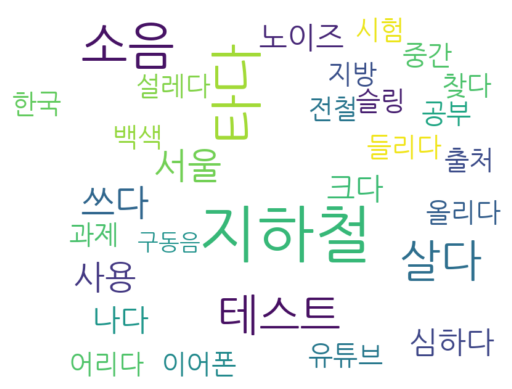

지하철의 상위 단어 3개: [('지하철', 19), ('타다', 14), ('소음', 12)]




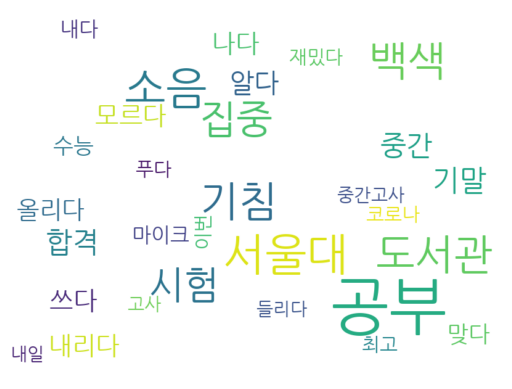

도서관의 상위 단어 3개: [('공부', 98), ('서울대', 43), ('소음', 42)]




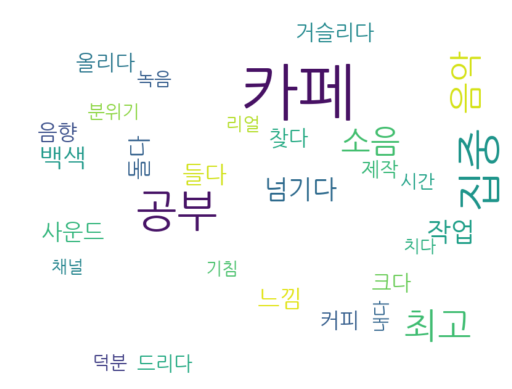

카페의 상위 단어 3개: [('카페', 83), ('집중', 37), ('공부', 35)]




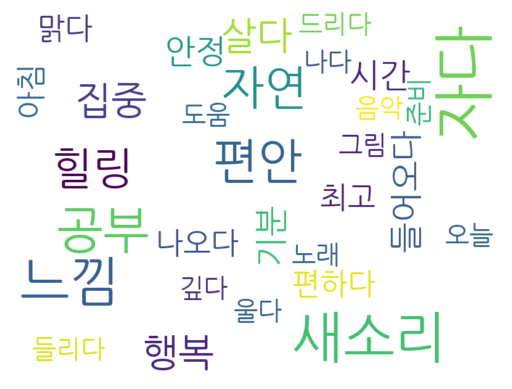

숲의 상위 단어 3개: [('자다', 19), ('새소리', 15), ('느낌', 14)]




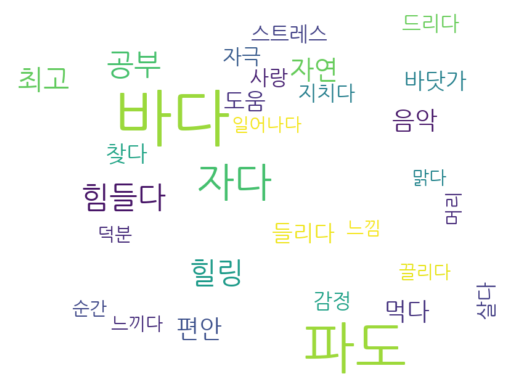

바다의 상위 단어 3개: [('바다', 61), ('파도', 48), ('자다', 22)]




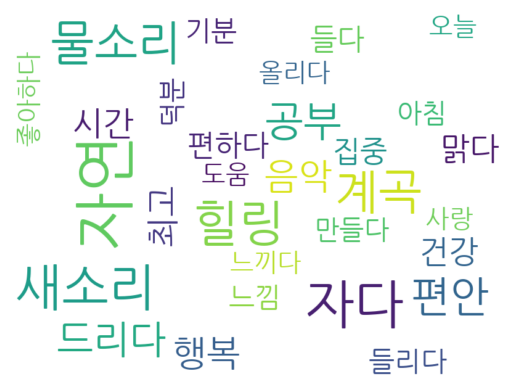

계곡의 상위 단어 3개: [('자연', 54), ('자다', 38), ('새소리', 34)]




In [ ]:
# 워드 클라우드 생성
for label, words in all_words.items():
    wc = make_word_cloud(words, label)
    all_word_clouds[label] = wc

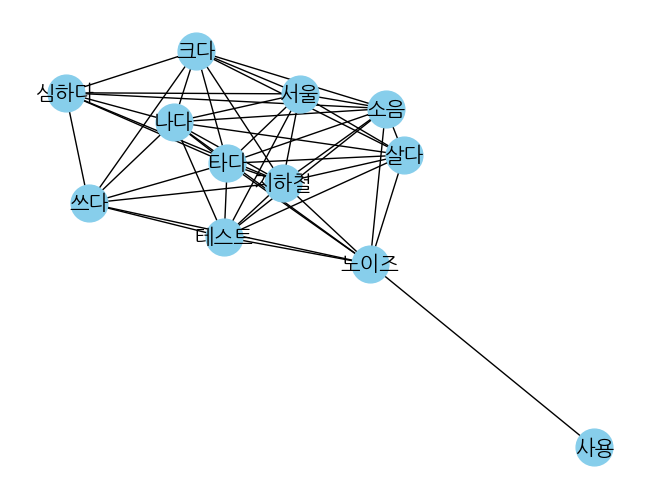

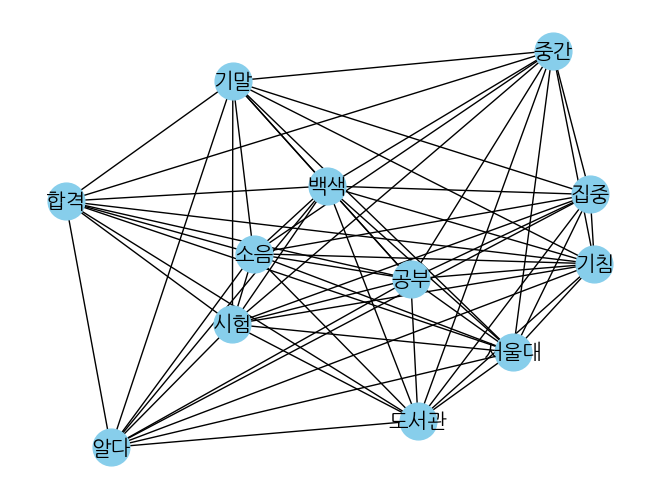

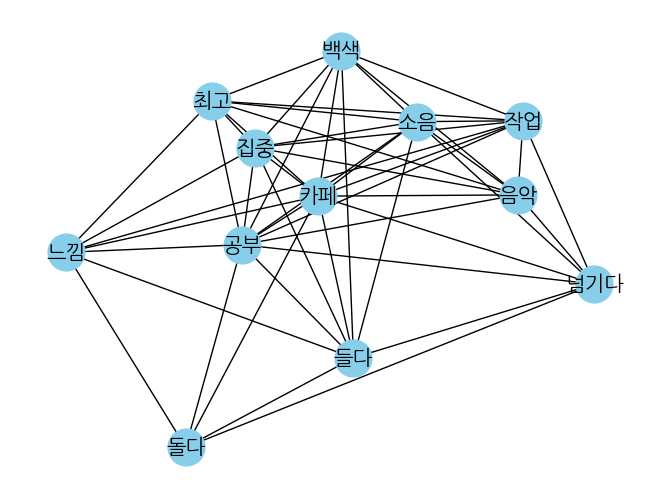

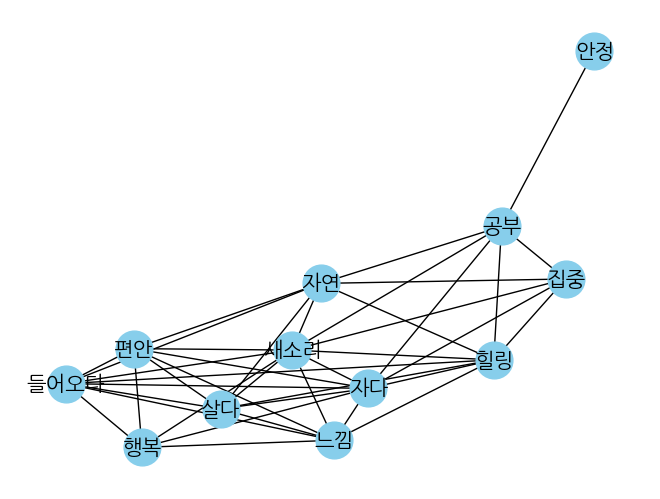

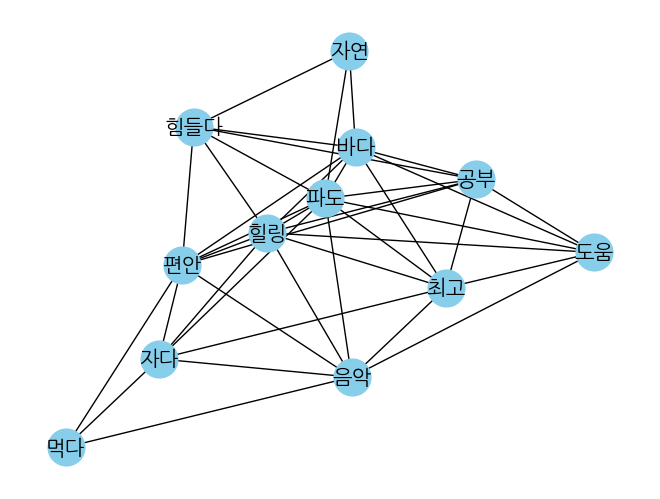

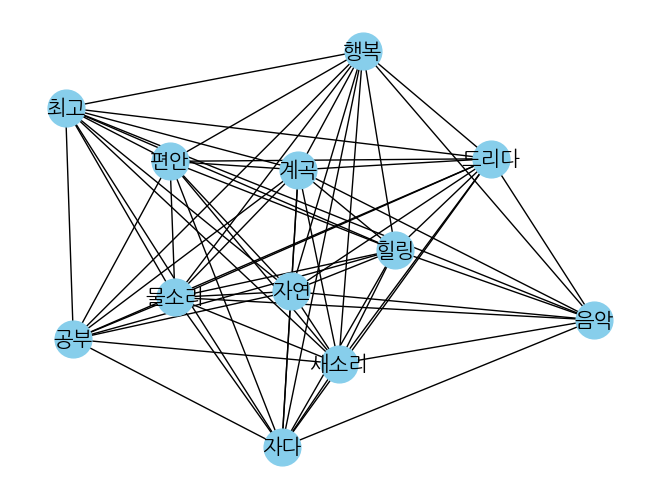

In [ ]:
# 네트워크 그래프 생성
for label, filename in texts.items():
    with open(filename, 'r', encoding = 'utf-8')as f:
        content = f.read()

    sentences = get_sentences(content, customized_stopwords)
    c = Counter(all_words[label])
    selected = get_words(c)

    g = do_na(sentences, selected, label)
    all_networks[label] = g

# 4. 데이터 분석

### 라이브러리 임포트

In [ ]:
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## 분석 1: 문서 벡터화 및 유사도

### TF-IDF 생성

In [ ]:
total_doc = []

for label, words in all_words.items():
    filtered = ' '. join(words)
    total_doc.append(filtered)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1,1))
DTM_tfidf = tfidf_vectorizer.fit_transform(total_doc)

DTM_TFIDF = np.array(DTM_tfidf.todense())
dtm_tfidf_name = tfidf_vectorizer.get_feature_names_out()

In [ ]:
DTM_TFIDF.shape

(6, 459)

In [ ]:
df_DTM_TFIDF = pd.DataFrame(data=DTM_TFIDF, columns=dtm_tfidf_name, index = list(all_words.keys()))
df_DTM_TFIDF.to_csv('DTM_TFIDF.csv', index=False, encoding='utf-8')
df_DTM_TFIDF

,가능,가사,가슴,가족,가지다,간접,강력,강아지,갖다,걱정,...,화장실,환경,효율,후회,휴대폰,휴식,흐르다,희망,힐링,힘내다
지하철,0.065775,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.045458,0.000000,0.032887
도서관,0.008532,0.000000,0.000000,0.000000,0.008532,0.011794,0.000000,0.000000,0.009957,0.011794,...,0.011794,0.009957,0.011794,0.011794,0.019914,0.000000,0.000000,0.000000,0.000000,0.034130
카페,0.000000,0.027639,0.000000,0.000000,0.019996,0.000000,0.027639,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.027639,0.000000,0.000000,0.023335,0.000000,0.000000,0.000000,0.019996
숲,0.031415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.086846,0.000000,0.000000,...,0.000000,0.036661,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.329946,0.000000
바다,0.008885,0.000000,0.012281,0.012281,0.026655,0.000000,0.012281,0.000000,0.010369,0.000000,...,0.000000,0.010369,0.000000,0.000000,0.010369,0.020737,0.012281,0.012281,0.103686,0.008885
계곡,0.000000,0.017364,0.017364,0.052093,0.012563,0.017364,0.000000,0.017364,0.014660,0.034728,...,0.034728,0.000000,0.000000,0.017364,0.029320,0.058640,0.104185,0.000000,0.469121,0.000000


각 문서별 TF-IDF 상위 단어 10개 추출

In [ ]:
for i, label in enumerate(list(all_words.keys())):
    tfidf_scores = DTM_TFIDF[i]
    top_words = tfidf_scores.argsort()[::-1][:10]
    print(f'\n{label} 상위 TF-IDF 단어')
    for idx in top_words:
        print(f"{dtm_tfidf_name[idx]}: {tfidf_scores[idx]:.4f}")


지하철 상위 TF-IDF 단어
타다: 0.5373
테스트: 0.4091
소음: 0.3946
서울: 0.2727
심하다: 0.1535
노이즈: 0.1535
슬링: 0.1364
어리다: 0.1364
출처: 0.1151
유튜브: 0.0987

도서관 상위 TF-IDF 단어
서울대: 0.5071
도서관: 0.4364
기침: 0.3684
소음: 0.3584
백색: 0.3072
합격: 0.1365
내리다: 0.1109
수능: 0.0996
이번: 0.0943
마이크: 0.0896

카페 상위 TF-IDF 단어
소음: 0.3599
작업: 0.2800
넘기다: 0.2800
돌다: 0.2764
커피: 0.2211
음향: 0.2211
백색: 0.2200
사운드: 0.2100
리얼: 0.1658
제작: 0.1633

숲 상위 TF-IDF 단어
새소리: 0.6513
힐링: 0.3299
행복: 0.2199
안정: 0.1571
맑다: 0.1466
앵무새: 0.1303
아침: 0.1257
바람: 0.1100
그림: 0.1100
노래: 0.1100

바다 상위 TF-IDF 단어
바다: 0.7491
파도: 0.5895
힐링: 0.1037
먹다: 0.0622
지치다: 0.0614
자극: 0.0614
스트레스: 0.0518
사랑: 0.0444
맑다: 0.0415
머리: 0.0415

계곡 상위 TF-IDF 단어
새소리: 0.5904
힐링: 0.4691
행복: 0.2136
맑다: 0.1906
건강: 0.1633
아침: 0.1131
흐르다: 0.1042
보내다: 0.1042
명상: 0.1026
사랑: 0.1005


### 문서간 유사도: 유클리디안 거리, 코사인 유사도

In [ ]:
print(np.linalg.norm(DTM_TFIDF[1]-DTM_TFIDF[0])) # 첫 번째 문서와 두 번째 문서 간의 유클리디안 거리
print(np.linalg.norm(DTM_TFIDF[2]-DTM_TFIDF[0])) # 첫 번째 문서와 세 번째 문서 간의 유클리디안 거리
print(np.linalg.norm(DTM_TFIDF[2]-DTM_TFIDF[1])) # 두 번째 문서와 세 번째 문서 간의 유클리디안 거리

1.2163919638553529
1.2408155044237017
1.1116781536006357


In [ ]:
print(np.dot(DTM_TFIDF[0],DTM_TFIDF[1])/(np.linalg.norm(DTM_TFIDF[0])*np.linalg.norm(DTM_TFIDF[1])))
print(np.dot(DTM_TFIDF[0],DTM_TFIDF[2])/(np.linalg.norm(DTM_TFIDF[0])*np.linalg.norm(DTM_TFIDF[2])))
print(np.dot(DTM_TFIDF[1],DTM_TFIDF[2])/(np.linalg.norm(DTM_TFIDF[1])*np.linalg.norm(DTM_TFIDF[2])))

0.2601952951340607
0.230188441990879
0.38208584140354324


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

cos_sim = cosine_similarity(DTM_TFIDF)
df_cos = pd.DataFrame(cos_sim,
                      index=list(all_words.keys()),
                      columns=list(all_words.keys()))


euc_dist = euclidean_distances(DTM_TFIDF)
df_euc = pd.DataFrame(euc_dist,
                      index=list(all_words.keys()),
                      columns=list(all_words.keys()))

# 결과 출력
labels = list(all_words.keys())
n = len(labels)

mask = ~np.eye(n, dtype=bool)
rows, cols = np.where(mask)

# 유클리디안 거리 - 값이 작을수록 가까움
euc_values = euc_dist[mask]
euc_sim_idx = (rows[euc_values.argmin()], cols[euc_values.argmin()])
euc_diff_idx = (rows[euc_values.argmax()], cols[euc_values.argmax()])

# 코사인 유사도 - 값이 클수록 가까움
cos_values = cos_sim[mask]
cos_sim_idx = (rows[cos_values.argmax()], cols[cos_values.argmax()])
cos_diff_idx = (rows[cos_values.argmin()], cols[cos_values.argmin()])

# 결과 출력
print(f"유클리디안 거리: 약 {euc_values.min():.4f}으로, {labels[euc_sim_idx[0]]}와 {labels[euc_sim_idx[1]]} 가장 유사함")
print(f"유클리디안 거리: 약 {euc_values.max():.4f}으로, {labels[euc_diff_idx[0]]}와 {labels[euc_diff_idx[1]]} 가장 이질적")
print("\n")
print(f"코사인 유사도: 약 {cos_values.max():.4f}으로, {labels[cos_sim_idx[0]]}와 {labels[cos_sim_idx[1]]} 가장 유사함")
print(f"코사인 유사도: 약 {cos_values.min():.4f}으로, {labels[cos_diff_idx[0]]}와 {labels[cos_diff_idx[1]]} 가장 이질적")

유클리디안 거리: 약 0.6828으로, 숲와 계곡 가장 유사함
유클리디안 거리: 약 1.3980으로, 지하철와 바다 가장 이질적


코사인 유사도: 약 0.7669으로, 숲와 계곡 가장 유사함
코사인 유사도: 약 0.0228으로, 지하철와 바다 가장 이질적


In [ ]:
df_euc

,지하철,도서관,카페,숲,바다,계곡
지하철,0.000000,1.216392,1.240816,1.389161,1.398010,1.338828
도서관,1.216392,0.000000,1.111678,1.385256,1.393780,1.304185
카페,1.240816,1.111678,0.000000,1.352786,1.370970,1.316671
숲,1.389161,1.385256,1.352786,0.000000,1.350425,0.682756
바다,1.398010,1.393780,1.370970,1.350425,0.000000,1.280276
계곡,1.338828,1.304185,1.316671,0.682756,1.280276,0.000000


In [ ]:
df_cos

,지하철,도서관,카페,숲,바다,계곡
지하철,1.000000,0.260195,0.230188,0.035115,0.022784,0.103770
도서관,0.260195,1.000000,0.382086,0.040533,0.028689,0.149550
카페,0.230188,0.382086,1.000000,0.084985,0.060221,0.133188
숲,0.035115,0.040533,0.084985,1.000000,0.088177,0.766922
바다,0.022784,0.028689,0.060221,0.088177,1.000000,0.180447
계곡,0.103770,0.149550,0.133188,0.766922,0.180447,1.000000


## 분석 2: K-Means 군집화 및 PCA

### PCA (차원 축소)

In [ ]:
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# 459 차원의 원데이터 -> 3차원으로 축소
pca = PCA(n_components=3)
pca_results_tfidf = pca.fit_transform(DTM_TFIDF)

In [ ]:
pca.explained_variance_ratio_

array([0.35735147, 0.24568447, 0.19335951])

In [ ]:
# 2차원 -> 60 % 정도 원데이터 설명
pca1 = PCA(n_components=2)
pca1_results = pca1.fit_transform(DTM_TFIDF)
pca1.explained_variance_ratio_
sum(pca1.explained_variance_ratio_)

np.float64(0.6030359467177184)

In [ ]:
# 3차원 -> 80 % 정도 원데이터 설명
sum(pca.explained_variance_ratio_)

np.float64(0.7963954537706822)

### K_Means 적용 (축소한 차원을 군집화)

In [ ]:
# 실루엣 스코어: 내가 나는 군집이 얼마나 완벽하게 잘 나뉘었는가?
# 응집도: 같은 군집 안 묶인 문서들이 서로 끈끈하게 모여있는가?
# 분리도: 서로 다른 군집들이 경계선 없이 겹치지 않고, 명확히 떨어져 있는가?
# 범위: -1 ~ +1 -> +1에 가까울 수록 군집화 잘 되었다고 볼 수 있음

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_pca_tfidf = kmeans.fit_predict(pca_results_tfidf)

# 1. PCA로 차원을 축소한 공간 안에서 군집들이 얼마나 잘 나뉘었는가?
print(silhouette_score(pca_results_tfidf, clusters_pca_tfidf))

# 2. 원자료에서 내가 나눈 군집들이 얼마나 잘 나뉘었는가?
clusters_tfidf = kmeans.fit_predict(DTM_TFIDF)
print(silhouette_score(DTM_TFIDF, clusters_tfidf))

# 3. PCA로 만든 군집들이 원본 공간에서도 잘 통하는가?
print(silhouette_score(DTM_TFIDF, clusters_pca_tfidf))

0.42713818205528925
0.12451235721996945
0.12451235721996945


군집화 분석 결과 시각화

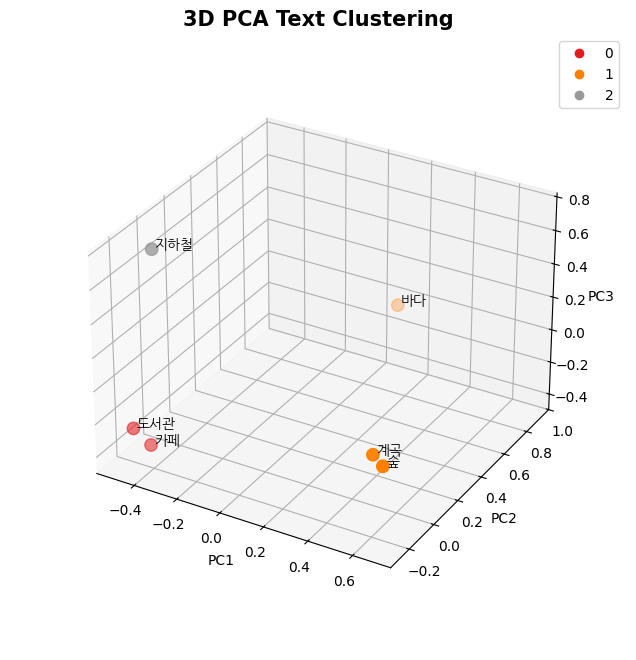

In [ ]:
data = pd.DataFrame(pca_results_tfidf, columns=['PC1', 'PC2','PC3'])
data['cluster_id']=clusters_pca_tfidf.tolist()

%matplotlib inline

labels = list(all_words.keys())
data['label'] = labels

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax. scatter(data['PC1'], data['PC2'],data['PC3'],
                      c=data['cluster_id'],
                      cmap='Set1',
                      s=80)

for i, row in data.iterrows():
    ax.text(row['PC1'] + 0.01, row['PC2'] + 0.01, row['PC3'],
            row['label'],
            fontproperties=font_prop,
            fontsize=10)

ax.set_title('3D PCA Text Clustering', fontsize=15, fontweight = 'bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_box_aspect(None, zoom=0.85)
ax.legend(*scatter.legend_elements(), loc = 'upper right')

plt.show()

## 분석3: 토픽 모델링

### 라이브러리 임포트

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.4 MB/s eta 0:00:00


In [ ]:
pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.0 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim import corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 토픽 모델링 실행

In [ ]:
# 댓글 단위로 쪼개서 마스터 데이터프레임 구축
source_map = {'지하철':'인공음',
              '도서관':'인공음',
              '카페':'인공음',
              '숲':'자연음',
              '바다':'자연음',
              '계곡':'자연음'}

rows = []

for label, filename in texts.items():
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        clean_line = line.strip()
        if len(clean_line) > 5:
            words = do_KOR_preprocessing(clean_line, customized_stopwords)
            if words:
                rows.append({
                    "raw_comment": clean_line,
                    "tokenized_words": words,
                    "source_type": source_map[label],
                    "sound_type": label
                })

df = pd.DataFrame(rows)

# LDA 토픽 모델링 수행
tokenized_docs = df["tokenized_words"].tolist()
dictionary = corpora.Dictionary(tokenized_docs)

dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

NUM_TOPICS = 3
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus, id2word=dictionary, num_topics=NUM_TOPICS, passes=15, random_state=42
)

# 시각화 파일 생성
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis_data, 'youtube_LDA_final.html')

### 토픽 모델링 결과

소리별 토픽 비율

In [ ]:
results = []
for doc_bow, label, source in zip(corpus, df['sound_type'], df['source_type']):
    topic_dist = dict(lda_model.get_document_topics(doc_bow))
    topic_dist['sound_type'] = label
    topic_dist['source_type'] = source
    results.append(topic_dist)

result_df = pd.DataFrame(results).fillna(0)
result_df.groupby('sound_type')[[0, 1, 2]].mean()

,0,1,2
sound_type,,,
계곡,0.336446,0.320417,0.343137
도서관,0.254401,0.301555,0.444044
바다,0.355061,0.343226,0.301712
숲,0.301076,0.322214,0.376710
지하철,0.217995,0.434125,0.347879
카페,0.454142,0.254243,0.291615


토픽별 상위 단어 10개 추출

In [ ]:
for i in range(NUM_TOPICS):
    print(f'\n토픽 {i}:')
    print(lda_model.print_topic(i, topn=10))


토픽 0:
0.062*"카페" + 0.050*"바다" + 0.042*"집중" + 0.042*"최고" + 0.029*"드리다" + 0.027*"들다" + 0.026*"시간" + 0.023*"행복" + 0.022*"자다" + 0.021*"계곡"

토픽 1:
0.045*"새소리" + 0.044*"파도" + 0.033*"힐링" + 0.028*"음악" + 0.026*"물소리" + 0.025*"들리다" + 0.025*"시험" + 0.023*"살다" + 0.020*"중간" + 0.020*"느끼다"

토픽 2:
0.115*"공부" + 0.052*"소음" + 0.049*"자연" + 0.044*"자다" + 0.037*"백색" + 0.029*"편안" + 0.028*"서울대" + 0.026*"집중" + 0.024*"도서관" + 0.021*"느낌"


토픽 모델링 결과 시각화

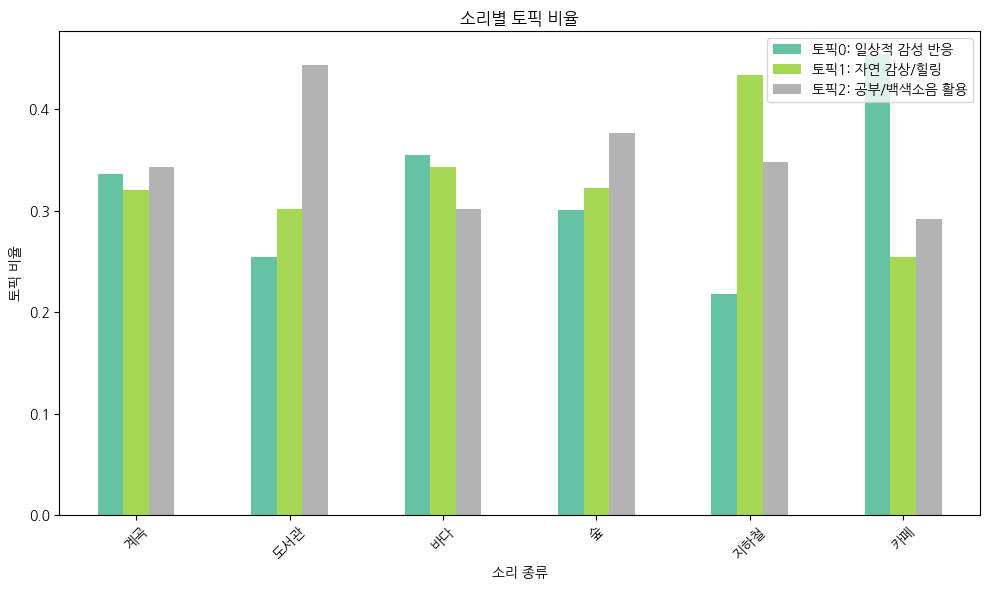

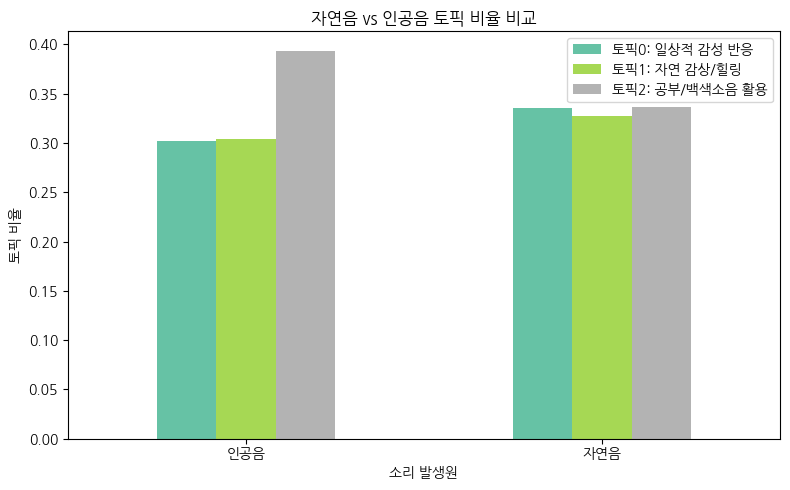

In [ ]:
plt.rcParams['font.family'] = font_name

topic_mean = result_df.groupby('sound_type')[[0, 1, 2]].mean()
topic_mean.columns = ['토픽0: 일상적 감성 반응', '토픽1: 자연 감상/힐링', '토픽2: 공부/백색소음 활용']

# 1. 소리별 토픽 비율 막대그래프
topic_mean.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('소리별 토픽 비율')
plt.ylabel('토픽 비율')
plt.xlabel('소리 종류')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('topic_by_sound.png', dpi=150)
plt.show()

# 2. 자연음 vs 인공음 비교
source_mean = result_df.groupby('source_type')[[0, 1, 2]].mean()
source_mean.columns = ['토픽0: 일상적 감성 반응', '토픽1: 자연 감상/힐링', '토픽2: 공부/백색소음 활용']

source_mean.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('자연음 vs 인공음 토픽 비율 비교')
plt.ylabel('토픽 비율')
plt.xlabel('소리 발생원')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('topic_by_source.png', dpi=150)
plt.show()

# 5. 모델 성능 평가

###라이브러리 임포트

In [ ]:
from gensim.models import CoherenceModel

###Coherence Score 계산

In [ ]:
coherence_model = CoherenceModel(
    model=lda_model,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()

print(f"Coherence Score (C_v): {coherence_score:.4f}")

Coherence Score (C_v): 0.4640


In [ ]:
topic_nums = range(2, 11)
coherence_scores = []

for k in topic_nums:

    temp_lda = gensim.models.ldamodel.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=15,
        random_state=42
    )

    coherence_model = CoherenceModel(
        model=temp_lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = coherence_model.get_coherence()
    coherence_scores.append(score)

    print(f"토픽 수 {k}: Coherence = {score:.4f}")

토픽 수 2: Coherence = 0.3969
토픽 수 3: Coherence = 0.4640
토픽 수 4: Coherence = 0.4827
토픽 수 5: Coherence = 0.5073
토픽 수 6: Coherence = 0.5327
토픽 수 7: Coherence = 0.5323
토픽 수 8: Coherence = 0.5391
토픽 수 9: Coherence = 0.5424
토픽 수 10: Coherence = 0.5650


### Coherence 결과 시각화

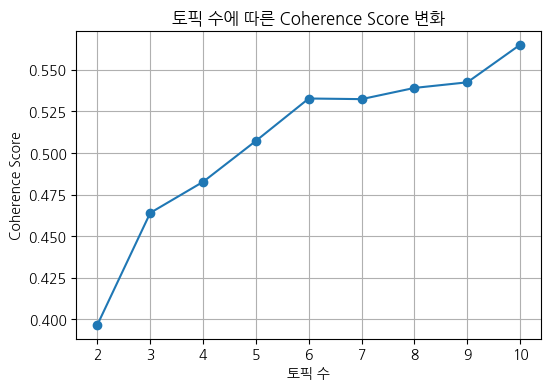

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(topic_nums, coherence_scores, marker='o')
plt.xlabel('토픽 수')
plt.ylabel('Coherence Score')
plt.title('토픽 수에 따른 Coherence Score 변화')
plt.grid(True)
plt.show()